# Tâche 4 — CNN optimisé + Temperature Scaling

Ce notebook couvre la Tâche 4 :
- Entraîner un CNN (sortie logits)
- Appliquer une calibration Temperature Scaling
- Analyser la confiance des prédictions
- Sauvegarder les activations intermédiaires

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_dataset_split
from src.data.preprocess import preprocess_dataset
from src.models.cnn import (
    build_cnn_classifier,
    train_cnn_classifier,
    predict_logits,
    predict_probabilities,
    extract_intermediate_activations,
)
from src.models.calibration import TemperatureScaler, summarize_confidence_distribution, analyze_uncertain_predictions

2026-03-02 16:20:31.160534: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 16:20:31.160990: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 16:20:31.259218: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 16:20:32.822712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# Paramètres (mode notebook rapide recommandé)
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'

IMG_SIZE = (32, 32)
EPOCHS = 3
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.3
TS_EPOCHS = 100
UNCERTAINTY_THRESHOLD = 0.7
ACTIVATION_SAMPLES = 128
ACTIVATIONS_PATH = PROJECT_ROOT / 'artifacts' / 'models' / 'cnn_task4_activations_notebook.npz'

assert TRAIN_DIR.exists(), f'Dossier introuvable: {TRAIN_DIR}'
assert TEST_DIR.exists(), f'Dossier introuvable: {TEST_DIR}'

print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR :', TEST_DIR)
print(f'IMG_SIZE={IMG_SIZE}, EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, TS_EPOCHS={TS_EPOCHS}')

TRAIN_DIR: /mnt/data/vmenon/Other_Work/Projet_ML/data/Training
TEST_DIR : /mnt/data/vmenon/Other_Work/Projet_ML/data/Testing
IMG_SIZE=(32, 32), EPOCHS=3, BATCH_SIZE=128, TS_EPOCHS=100


## 1) Chargement et préparation des données

In [3]:
train_split = load_dataset_split(TRAIN_DIR, image_size=IMG_SIZE)
test_split = load_dataset_split(TEST_DIR, image_size=IMG_SIZE, class_names=train_split.class_names)

x_train_all, y_train_all = preprocess_dataset(
    train_split.images,
    train_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)
x_test, y_test = preprocess_dataset(
    test_split.images,
    test_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False,
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all,
)

print('Train:', x_train.shape, y_train.shape)
print('Val  :', x_val.shape, y_val.shape)
print('Test :', x_test.shape, y_test.shape)
print('Classes:', train_split.class_names)

Train: (4480, 32, 32, 3) (4480,)
Val  : (1120, 32, 32, 3) (1120,)
Test : (1600, 32, 32, 3) (1600,)
Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']


## 2) Entraînement du CNN

In [4]:
num_classes = len(train_split.class_names)
model = build_cnn_classifier(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
)

history = train_cnn_classifier(
    model=model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

2026-03-02 16:20:45.506575: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5355 - loss: 1.0615 - val_accuracy: 0.6598 - val_loss: 0.8154
Epoch 2/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.7221 - loss: 0.7261 - val_accuracy: 0.7777 - val_loss: 0.6234
Epoch 3/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.7777 - loss: 0.5891 - val_accuracy: 0.7821 - val_loss: 0.5193


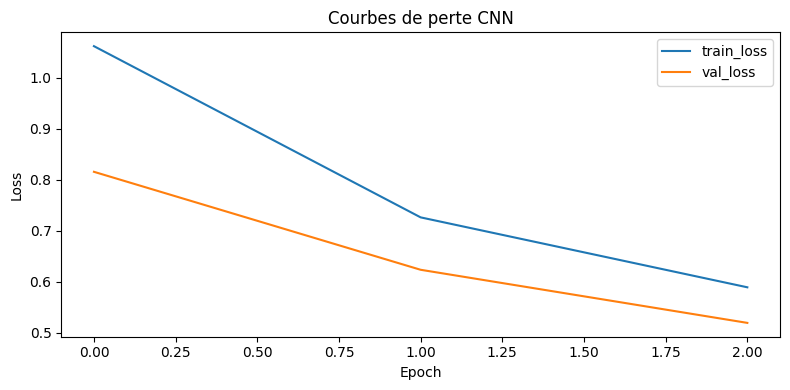

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Courbes de perte CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 3) Évaluation de base (sans calibration)

In [6]:
probs_base = predict_probabilities(model, x_test)
preds_base = np.argmax(probs_base, axis=1)
acc_base = accuracy_score(y_test, preds_base)
print(f'Accuracy CNN base: {acc_base:.4f}')

Accuracy CNN base: 0.7050


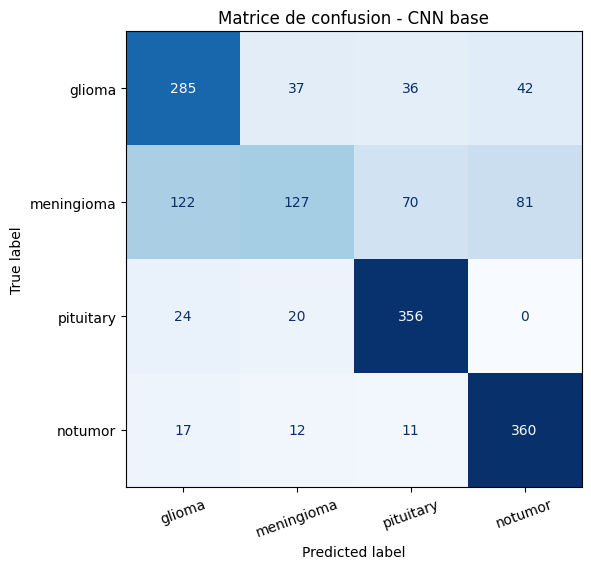

In [7]:
cm = confusion_matrix(y_test, preds_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_split.class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matrice de confusion - CNN base')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4) Temperature Scaling

In [8]:
val_logits = predict_logits(model, x_val)
test_logits = predict_logits(model, x_test)

temp_scaler = TemperatureScaler(initial_temperature=1.0)
temp_scaler.fit(
    logits=val_logits,
    labels=y_val,
    learning_rate=1e-2,
    epochs=TS_EPOCHS,
    verbose=0,
)

probs_cal = temp_scaler.predict_proba(test_logits)
preds_cal = np.argmax(probs_cal, axis=1)
acc_cal = accuracy_score(y_test, preds_cal)

print(f'Température apprise: {temp_scaler.temperature:.4f}')
print(f'Accuracy calibrée : {acc_cal:.4f}')

Température apprise: 0.9400
Accuracy calibrée : 0.7050


In [9]:
max_prob = np.max(probs_cal, axis=1)
confidence_stats = summarize_confidence_distribution(max_prob)
uncertain_stats = analyze_uncertain_predictions(max_prob, threshold=UNCERTAINTY_THRESHOLD)

print('Distribution max_prob calibrée:')
print('  p25={p25:.3f} | p50={p50:.3f} | p75={p75:.3f} | mean={mean:.3f} | std={std:.3f}'.format(**confidence_stats))
print(f"Incertains (<{UNCERTAINTY_THRESHOLD:.2f}): {uncertain_stats['uncertain_count']}/{uncertain_stats['total']} ({100*uncertain_stats['uncertain_ratio']:.2f}%)")

Distribution max_prob calibrée:
  p25=0.628 | p50=0.828 | p75=0.944 | mean=0.781 | std=0.180
Incertains (<0.70): 537/1600 (33.56%)


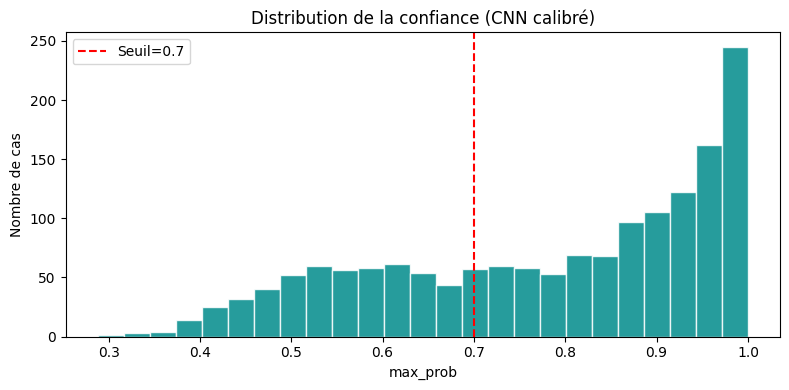

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(max_prob, bins=25, color='darkcyan', alpha=0.85, edgecolor='white')
plt.axvline(UNCERTAINTY_THRESHOLD, color='red', linestyle='--', label=f'Seuil={UNCERTAINTY_THRESHOLD}')
plt.title('Distribution de la confiance (CNN calibré)')
plt.xlabel('max_prob')
plt.ylabel('Nombre de cas')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Sauvegarde des activations intermédiaires

In [11]:
layer_names = ['conv1', 'conv2', 'conv3', 'dense1']
n_samples = min(ACTIVATION_SAMPLES, x_test.shape[0])
activations = extract_intermediate_activations(
    model=model,
    x_data=x_test[:n_samples],
    layer_names=layer_names,
    batch_size=BATCH_SIZE,
)

ACTIVATIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    ACTIVATIONS_PATH,
    sample_images=x_test[:n_samples],
    sample_labels=y_test[:n_samples],
    class_names=np.array(train_split.class_names),
    **{f'activation_{name}': activations[name] for name in layer_names},
)

print('Activations sauvegardées dans:', ACTIVATIONS_PATH)
for name in layer_names:
    print(f'- {name:<8}: {activations[name].shape}')

Activations sauvegardées dans: /mnt/data/vmenon/Other_Work/Projet_ML/artifacts/models/cnn_task4_activations_notebook.npz
- conv1   : (128, 32, 32, 32)
- conv2   : (128, 16, 16, 64)
- conv3   : (128, 8, 8, 128)
- dense1  : (128, 256)
